In [1]:
import sys

import os


In [18]:
import wandb
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from torch.utils.data import DataLoader
from xaikd.utils import metrics, constants
from xaikd import models, datasets

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

from torchvision import transforms

from collections import OrderedDict

from datetime import datetime

from matplotlib.ticker import StrMethodFormatter



In [19]:
api = wandb.Api()

In [20]:
PROJECT = "p16i/kitchen-sink"

In [49]:
def read_data(
    teacher, student,
    dataset,
    dataset_variant,
    arr_policies,
    output_dir,
    training_size=1.0,
    verbose=False,
    num_seeds=3,
    lambda_task=0,
    lambda_kd=1,
):
    
    
#     if policy == "fitnet":
#         policy = resolve_fitnet(teacher, verbose=verbose)

#     if policy == "kd_only":
#         policy = "nothing"
#         lambda_kd = 1
#         lambda_task = 0

    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": dataset},
            {"config.dataset-variant": dataset_variant},
            {"config.training_size": training_size},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": {"$in": arr_policies}},
            {"config.output-dir": output_dir}
        ]
        }
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        
        best_val_acc = run.summary["arr_metrics"]["val_acc"][-1]
    
        best_train_acc = run.summary["arr_metrics"]["train_acc"][-1]


        rows.append(
            dict(
                val_acc=best_val_acc, 
                train_acc=best_train_acc,
                teacher_acc=run.summary["teacher_acc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    df = df.groupby("policy").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "teacher_acc": ["mean", "std", "count"],
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"],
        num_seeds
    )
    
    return df
  
_df = read_data(
    teacher="imagenet-resnet18-tv",
    student="student-32-24-16-8",
    arr_policies=[
        "attention-transfer",
        "basis-identity:pca--uncentered"
    ],
    dataset="imagenet-butterfly",
    dataset_variant="spurious-watermarkC0--1.0",
    output_dir="/tmp/spurious-multiple-class",
    verbose=True,
)

_df

we have 6 runs


policy   val_acc                 teacher_acc       \
                                       mean       std count        mean  std   
0              attention-transfer  0.771111  0.006939     3        0.87  0.0   
1  basis-identity:pca--uncentered  0.811111  0.022194     3        0.87  0.0   

         
  count  
0     3  
1     3

In [90]:
 read_data(
    teacher="imagenet-resnet18-tv",
    student="student-32-24-16-8",
    arr_policies=[
        "attention-transfer",
#         "basis-identity:pca--uncentered",
#         "basis-identity:pcalookahead--uncentered"
    ],
    dataset="imagenet-butterfly",
    dataset_variant="spurious-copyrightwatermarkjpeg--1.0",
    output_dir="/tmp/spurious-threespurious",
    verbose=True,
)


we have 3 runs


policy   val_acc                 teacher_acc           
                           mean       std count        mean  std count
0  attention-transfer  0.736667  0.029627     3    0.923333  0.0     3

# Vis: All Images have JPEG Artifacts. C0 has watermark

In [91]:
OUTPUT_DIR_SETTING_MAPPING = {
    # remark: key=(dataset, variant, output_dir)
    "allJPEG-C0Watermark": ("imagenet-butterfly", "spurious-watermarkC0--1.0", "/tmp/spurious-multiple-class"),
    "allBlur-C0Watermark": ("imagenet-butterfly", "spurious-watermarkC0--1.0", "/tmp/spurious-blurring-images"),
    "threespurious": ("imagenet-butterfly", "spurious-copyrightwatermarkjpeg--1.0", "/tmp/spurious-threespurious")
}

In [58]:
def basis_alias(name):
        __dd = {
            "basis-identity:random--uncentered": "Random Subspace",
            "basis-identity:pca--uncentered": "PCA",
            "basis-identity:pcalookahead--uncentered": "PCA-AH",
            "basis-identity:prca-sortabs--uncentered": "PRCA",
            "vid": "VID",
            "attention-transfer": "AT",
            "fitnet": "FitNet",
            "fitnet-relu": "FitNet",

            "nothing": "KD Only"
        }
        return __dd.get(name, name)



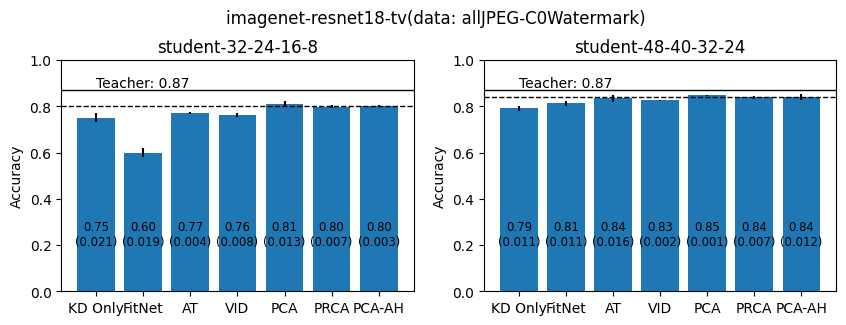

In [109]:
def viz(
    teacher,
    arr_students,
    setting,
    arr_policies=[
        "nothing",
        "fitnet-relu",
        "attention-transfer",
        "vid",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:pcalookahead--uncentered",
    ]
):
    
    dataset, dataset_variant, output_dir = OUTPUT_DIR_SETTING_MAPPING[setting]
    
    arr_basis_aliaes = list(
        map(
            basis_alias,
            arr_policies
        )
    )
    
    ncols = len(arr_students)
    plt.figure(figsize=(5*ncols, 3))
    plt.suptitle(f"{teacher}(data: {setting})", y=1.05)
    
    
    for six, student in enumerate(arr_students):
        plt.subplot(1, ncols, six+1)
        plt.title(student)
        df = read_data(
            teacher=teacher,
            student=student,
            arr_policies=arr_policies,
            dataset=dataset,
            dataset_variant=dataset_variant,
            output_dir=output_dir,
            verbose=False,
        )

        ticks = np.arange(df.shape[0])

        stats = np.zeros((df.shape[0], 2))
        for pix, policy in enumerate(arr_policies):
            _df = df[df["policy"] == policy]
            mean = _df["val_acc"]["mean"].values[0]
            std = _df["val_acc"]["std"].values[0]
            count = _df["val_acc"]["count"].values[0]
            stats[pix, :] = mean, std / (count **0.5)
        

        plt.bar(
            ticks,
            stats[:, 0],
            yerr=stats[:, 1]
        )
        for pix in range(stats.shape[0]):
            plt.text(pix, 0.2, f"{stats[pix, 0]:.2f}\n({stats[pix, 1]:.3f})", ha="center", fontsize="small")
            
        teacher_acc = df["teacher_acc"]["mean"].values[0] 
        plt.xticks(ticks, arr_basis_aliaes)
        plt.axhline(teacher_acc, lw=1, color="k")
        plt.text(0, teacher_acc, f"Teacher: {teacher_acc:.2f}", va="bottom",)
        plt.axhline(stats[-1, 0], lw=1, color="k", ls="--")
        plt.ylabel("Accuracy")
        plt.ylim([0, 1])

viz(
    teacher="imagenet-resnet18-tv",
    arr_students=["student-32-24-16-8", "student-48-40-32-24"],
    setting="allJPEG-C0Watermark"
)

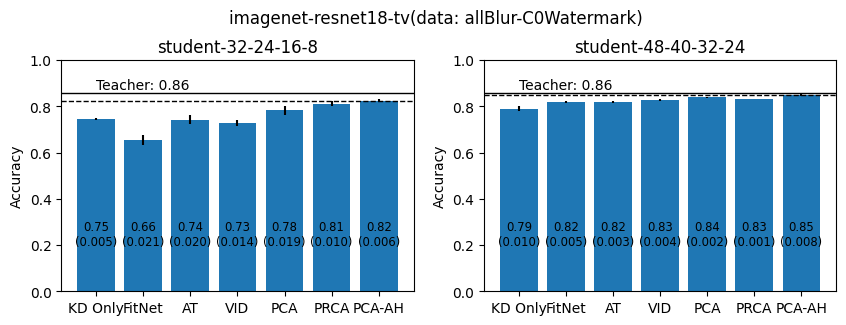

In [110]:
viz(
    teacher="imagenet-resnet18-tv",
    arr_students=["student-32-24-16-8", "student-48-40-32-24"],
    setting="allBlur-C0Watermark"
)

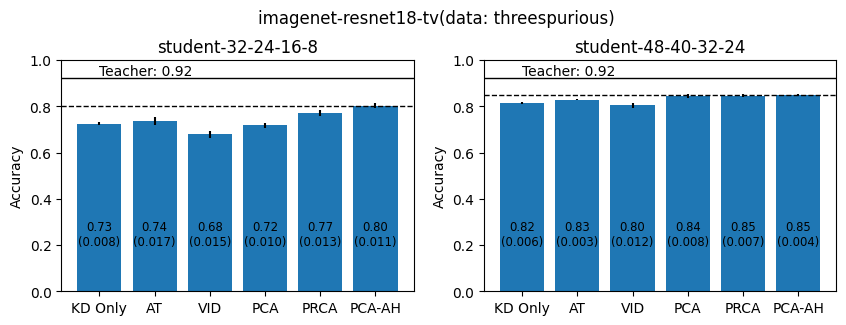

In [111]:
viz(
    teacher="imagenet-resnet18-tv",
    arr_students=[
        "student-32-24-16-8",
        "student-48-40-32-24"
    ],
    setting="threespurious",
    arr_policies=[
        "nothing",
#         "fitnet-relu",
        "attention-transfer",
        "vid",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:pcalookahead--uncentered",
    ]
)